In [1]:
import sys
sys.path.append("..")

from datetime import datetime


import jax
from jax import flatten_util, vmap 
import jax.numpy as jnp
import jax.random as jr
import os
import matplotlib.pyplot as plt
from physical_diffusion_fns.helper_fns import sample_gaussian_mixture, normalize_samples, sample_forward_process, get_best_params, smooth_parameters, interpolate_parameters
from physical_diffusion_fns.learning_fns import setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization, setup_score_matching_kbT_loss_per_batch, setup_score_matching_kbT_local_gradient_per_batch, setup_score_matching_kbT_loss_analytical
from physical_diffusion_fns.plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, plot_forward_marginals, visualize_connectivity, plot_parameter_as_fn_of_time, visualize_connectivity_with_non_local_couplings
from physical_diffusion_fns.network_fns import setup_overdamped_SDE, solve_SDE, create_2d_square_lattice_connectivity,setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_and_6th_order_energy_fn, setup_duffing_network_analytical_derivatives

jax.config.update("jax_enable_x64", True) 

2026-01-16 10:09:19.648031: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


# Random keys

In [2]:
master_key  = jax.random.PRNGKey(0)          # single seed
sample_target_key, optimization_key, reverse_sde_key = jr.split(master_key, 3)

# Generate samples from a Gaussian mixture - the target distribution

In [3]:
# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.6, .4])

# Define means
means = jnp.array([
    [1., 0.5],   # mean of first Gaussian
    [-1., -0.5],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.001, 0.0],    # covariance of first Gaussian
        [0.0, 0.001]],
    [[0.001, 0.0],   # covariance of second Gaussian
        [0.0, 0.001]],
])
# Generate samples
samples_target = sample_gaussian_mixture(sample_target_key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)

### Plot samples and marginal of target distributions

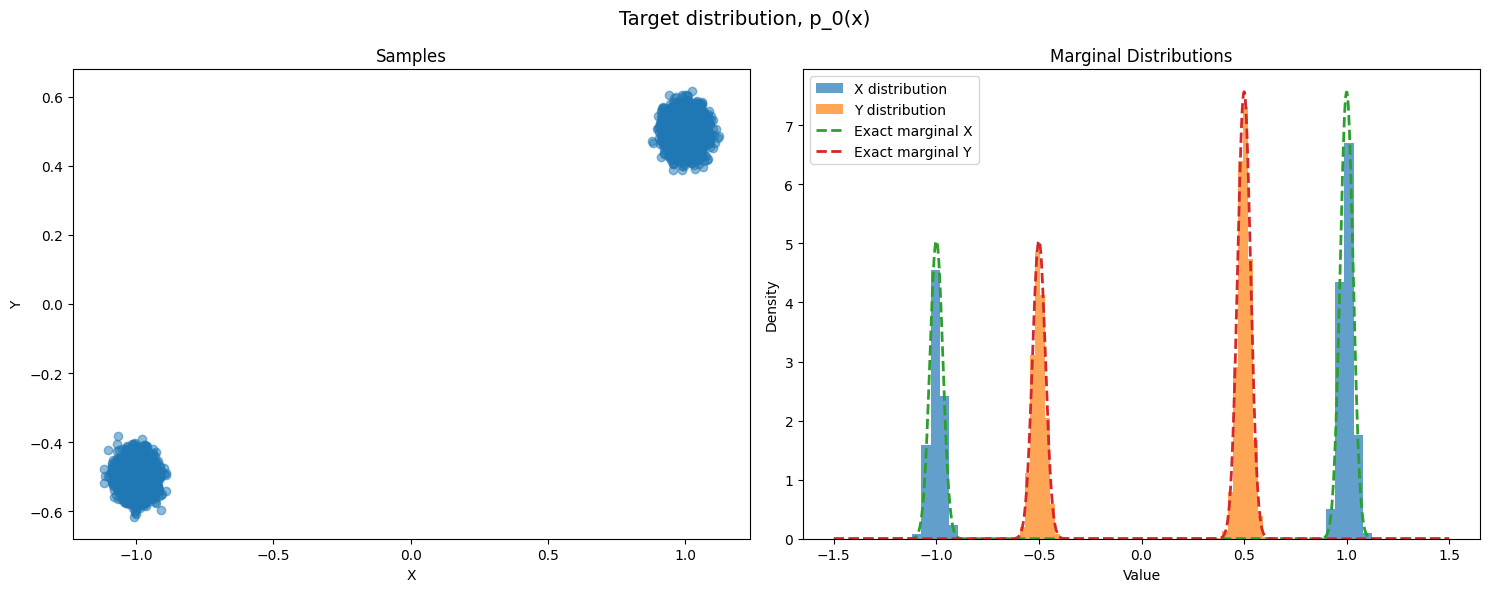

In [4]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_target[:, 0], samples_target[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_target[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_target[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

# Physical system

## Network size and topology and temperature

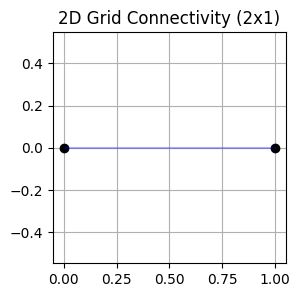

In [5]:
Temp = .1
N_osc = 2
connectivity = jnp.array([[0, 1]])
num_connections = connectivity.shape[0]
visualize_connectivity(connectivity,grid_size_x=2,grid_size_y=1)

## Energy

In [6]:
energy_fn_type = "6th_order_duffing_coupling"
if energy_fn_type == "6th_order_duffing_coupling":
    k_lin_0 = -1.*jnp.ones(N_osc)
    k_duff_0 = jnp.ones(N_osc)
    k_6_0 = jnp.ones(N_osc)
    c_lin_0 = jnp.zeros(num_connections)
    c_optomech_0 = jnp.zeros(num_connections)
    c_duff_0 = jnp.zeros(num_connections)
    biases_0 = jnp.zeros(N_osc)
    params_initial = (k_lin_0, k_duff_0, k_6_0, c_lin_0, c_optomech_0, c_duff_0, biases_0)
    params_names = ['k_lin', 'k_duff', 'k_6', 'c_lin', 'c_optomech', 'c_duff', 'biases']
    params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
    constraint_indices_k6_self = jnp.arange(2*N_osc,3*N_osc)
    constraint_indices = constraint_indices_k6_self

    # Set up energy fn
    energy_fn = setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_and_6th_order_energy_fn(connectivity, unflatten)
    # Set up analytical derivatives
    gradient_fn, trace_hessian_fn, gradient_wrt_params_fn, trace_hessian_wrt_params_fn = setup_duffing_network_analytical_derivatives(connectivity, unflatten)
elif energy_fn_type == "duffing_coupling":
    k_lin_0 = -1.*jnp.ones(N_osc)
    k_duff_0 = jnp.ones(N_osc)
    c_lin_0 = jnp.zeros(num_connections)
    c_optomech_0 = jnp.zeros(num_connections)
    c_duff_0 = jnp.zeros(num_connections)
    biases_0 = jnp.zeros(N_osc)
    params_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0, c_duff_0, biases_0)
    params_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech', 'c_duff', 'biases']
    params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
    constraint_indices_duff_self = jnp.arange(N_osc,2*N_osc)
    constraint_indices_duff_coupling = jnp.arange(2*N_osc+2*num_connections,2*N_osc+3*num_connections)
    constraint_indices = jnp.concatenate([constraint_indices_duff_self, constraint_indices_duff_coupling])
    # Set up energy fn
    energy_fn = setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_energy_fn(connectivity, unflatten)
    # Set up analytical derivatives
    gradient_fn, trace_hessian_fn, gradient_wrt_params_fn, trace_hessian_wrt_params_fn = setup_duffing_network_analytical_derivatives(connectivity, unflatten)
elif energy_fn_type == "duffing_optomech_coupling":
    k_lin_0 = -1.*jnp.ones(N_osc)
    k_duff_0 = jnp.ones(N_osc)
    c_lin_0 = jnp.zeros(num_connections)
    c_optomech_0 = jnp.zeros(num_connections)
    biases_0 = jnp.zeros(N_osc)
    params_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0, biases_0)
    params_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech', 'biases']
    params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
    constraint_indices = jnp.arange(N_osc,2*N_osc)
    # Set up energy fn
    energy_fn = setup_duffing_network_with_external_force_energy_fn(connectivity, unflatten)
    # Set up analytical derivatives (Note: this function is designed for 6th order duffing coupling, may need adjustment for other energy types)
    gradient_fn, trace_hessian_fn, gradient_wrt_params_fn, trace_hessian_wrt_params_fn = setup_duffing_network_analytical_derivatives(connectivity, unflatten)
else:
    raise ValueError(f"Unknown energy function type: {energy_fn_type}. Choose from '6th_order_duffing_coupling' or 'duffing_coupling'.")

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


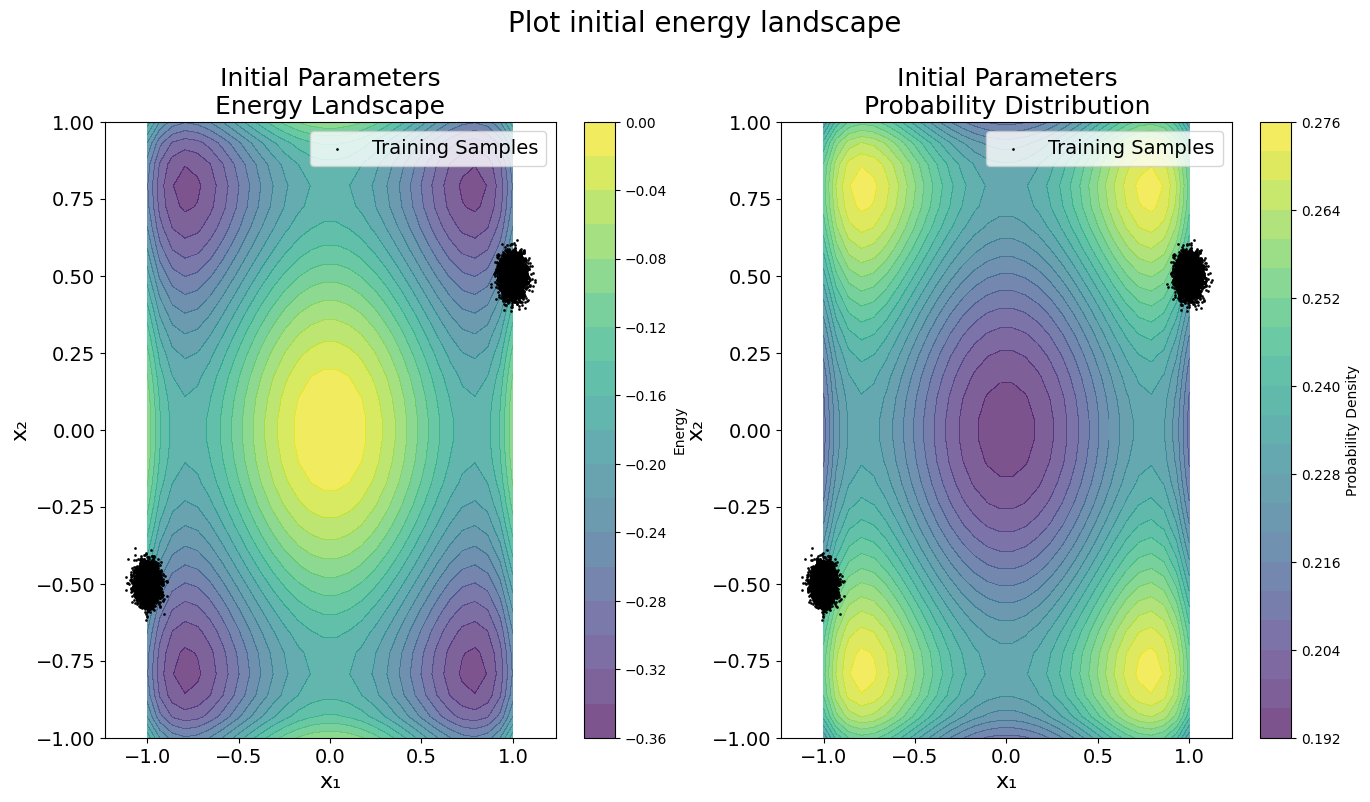

In [7]:
# Example usage:
param_list = [params_flattened_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_target,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Plot initial energy landscape" 
)

# Learning

In [8]:
# Choose training method
training_method = "SM_local"  # Options: "SM" (Score Matching), "CD1" (Contrastive Divergence), "MLE" (Maximum Likelihood)
if training_method == "SM":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = None
    maximize = False
elif training_method == "SM_local":
    # Use analytical version for much better performance
    loss_fn_per_batch, gradient_fn_per_batch = setup_score_matching_kbT_loss_analytical(
        gradient_fn, trace_hessian_fn, gradient_wrt_params_fn, trace_hessian_wrt_params_fn, 
        k_b=1.0, T=Temp
    )
    maximize = False
    learning_rate = Temp
elif training_method == "CD1":
    CD1_dt = 0.00001
    CD1_num_noise_samples = 3000
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = lambda flattened_args, batch, key_CD1: -CD1_gradient(energy_fn, batch, flattened_args, dt=CD1_dt, D=Temp, key=key_CD1, num_noise_samples=CD1_num_noise_samples)
    learning_rate = 0.01*Temp
    maximize = False
elif training_method == "MLE":
    loss_fn_per_batch = setup_MLE_loss_per_batch(energy_fn)
    gradient_fn_per_batch = setup_MLE_gradient_per_batch(energy_fn)
    maximize = True
else:
    raise ValueError(f"Unknown training method: {training_method}. Choose from 'SM', 'CD1', or 'MLE'.")


#### Optimization parameters and filenames

In [9]:
# Forward process parameters
n_time_steps = 5
t_forward = 5.
sigma_forward = 1.
exponential_time_pts = False
if exponential_time_pts:
    forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-7), jnp.log(t_forward), n_time_steps))
    forward_time_pts = forward_time_pts.at[0].set(0.)
else:
    forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)
# print('forward_time_pts', forward_time_pts)

# Optimization parameters

n_epochs = 100000
batch_size = 16*128
window_size=500
tolerance=1e-1
patience=100

In [10]:
problem_type_folder = f"gaussian_mixture/Energy_fn_type_{energy_fn_type}_Temp_{Temp}"
optimization_folder = (
        f"training_method_{training_method}_"
    + (f"CD1_dt_{CD1_dt}_CD1_num_noise_samples_{CD1_num_noise_samples}_" if training_method == "CD1" else "")
    + f"exp_time_pts_{exponential_time_pts}_"
    + f"t_forward_{t_forward}_"
    + f"n_timesteps_{n_time_steps}_"
        f"sigma_forward_{sigma_forward}_"
        f"lr_{learning_rate}_"
        f"epochs_{n_epochs}_"
        f"batch_{batch_size}_"
        f"window_{window_size}_"
        f"tol_{tolerance}_"
        f"patience_{patience}")

# Setup output directories
# here = os.path.dirname(os.path.abspath(__file__))
current_date = datetime.now().strftime("%Y_%m_%d")

base_dir = "../out/problems"
output_dir = os.path.join(base_dir, current_date,problem_type_folder, f"weights_{weights}_means_{means.flatten()}_covs_{covs.flatten()}", optimization_folder)
plot_folder = os.path.join(output_dir, 'aaa_final_plots')

# Create directories if they don't exist
os.makedirs(output_dir, exist_ok=True)
os.makedirs(plot_folder, exist_ok=True)
print(f"Output directory: {output_dir}")
print(f"Plot directory: {plot_folder}")

save_fig = False

Output directory: ../out/problems/2026_01_16/gaussian_mixture/Energy_fn_type_6th_order_duffing_coupling_Temp_0.1/weights_[0.6 0.4]_means_[ 1.   0.5 -1.  -0.5]_covs_[0.001 0.    0.    0.001 0.001 0.    0.    0.001]/training_method_SM_local_exp_time_pts_False_t_forward_5.0_n_timesteps_5_sigma_forward_1.0_lr_0.1_epochs_100000_batch_2048_window_500_tol_0.1_patience_100
Plot directory: ../out/problems/2026_01_16/gaussian_mixture/Energy_fn_type_6th_order_duffing_coupling_Temp_0.1/weights_[0.6 0.4]_means_[ 1.   0.5 -1.  -0.5]_covs_[0.001 0.    0.    0.001 0.001 0.    0.    0.001]/training_method_SM_local_exp_time_pts_False_t_forward_5.0_n_timesteps_5_sigma_forward_1.0_lr_0.1_epochs_100000_batch_2048_window_500_tol_0.1_patience_100/aaa_final_plots


t_idx: 0, t_curr: 0.0


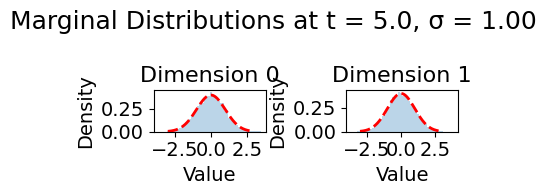

Epoch 0 - Loss: -11.5768 - Best Loss: -11.5768 (Epoch 0)
Epoch 100 - Loss: -471.3876 - Best Loss: -471.3876 (Epoch 100)
Epoch 200 - Loss: -689.8774 - Best Loss: -697.9058 (Epoch 196)
Epoch 300 - Loss: -795.0223 - Best Loss: -826.3715 (Epoch 299)
Epoch 400 - Loss: -835.2416 - Best Loss: -865.9570 (Epoch 385)
Epoch 500 - Loss: -888.3445 - Best Loss: -923.8450 (Epoch 490)
Epoch 600 - Loss: -866.4751 - Best Loss: -923.8450 (Epoch 490)
Epoch 700 - Loss: -890.3579 - Best Loss: -923.8450 (Epoch 490)
Epoch 800 - Loss: -922.2440 - Best Loss: -924.1508 (Epoch 729)
Epoch 900 - Loss: -893.0525 - Best Loss: -946.3849 (Epoch 821)
Epoch 1000 - Loss: -920.8592 - Best Loss: -950.2675 (Epoch 906)
Epoch 1100 - Loss: -952.4332 - Best Loss: -954.2117 (Epoch 1080)
Epoch 1200 - Loss: -916.6585 - Best Loss: -965.9330 (Epoch 1199)
Epoch 1300 - Loss: -937.8527 - Best Loss: -965.9330 (Epoch 1199)
Epoch 1400 - Loss: -915.6341 - Best Loss: -965.9330 (Epoch 1199)
Epoch 1500 - Loss: -938.9898 - Best Loss: -965.9657 

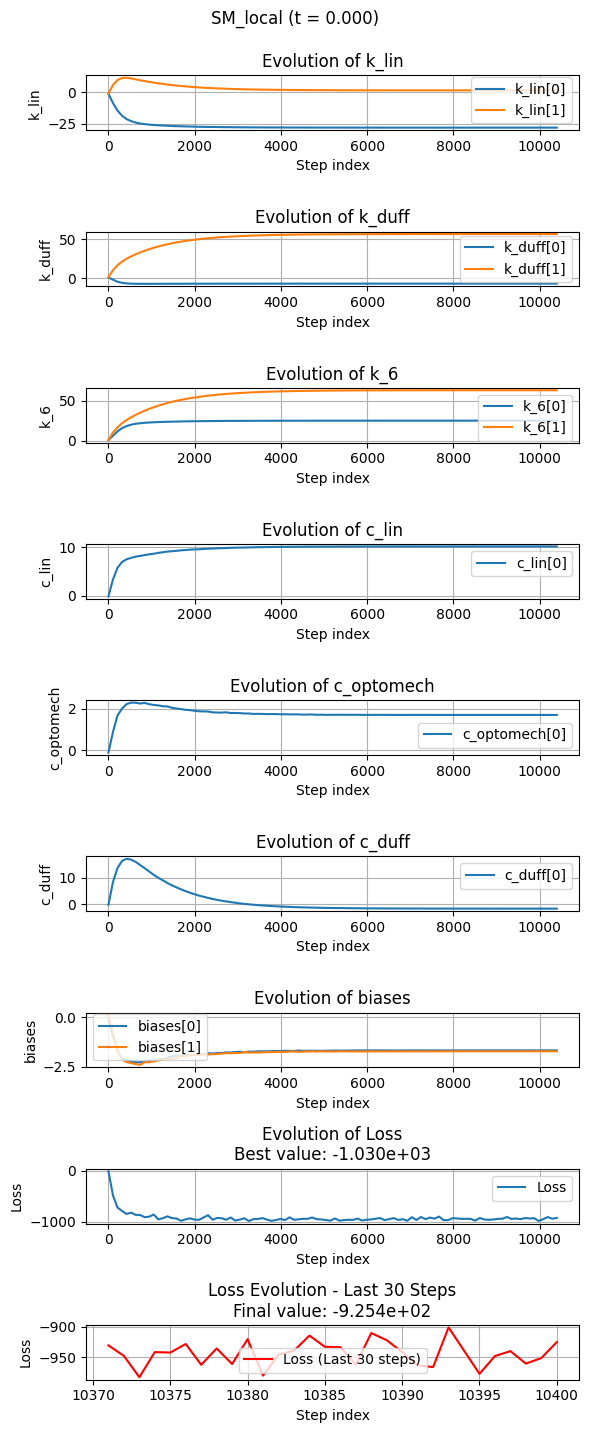

t_idx: 1, t_curr: 1.25
Epoch 0 - Loss: 26567.3487 - Best Loss: 26567.3487 (Epoch 0)
Epoch 100 - Loss: 17867.8207 - Best Loss: 6439.1686 (Epoch 95)
Epoch 200 - Loss: 3372.8677 - Best Loss: 3372.8677 (Epoch 200)
Epoch 300 - Loss: 3195.8390 - Best Loss: 1801.6364 (Epoch 279)
Epoch 400 - Loss: 1455.8941 - Best Loss: 1382.8707 (Epoch 341)
Epoch 500 - Loss: 10336.8421 - Best Loss: 1121.5179 (Epoch 495)
Epoch 600 - Loss: 2294.9754 - Best Loss: 1009.4554 (Epoch 592)
Epoch 700 - Loss: 1286.3924 - Best Loss: 737.0120 (Epoch 636)
Epoch 800 - Loss: 1263.1877 - Best Loss: 693.3531 (Epoch 756)
Epoch 900 - Loss: 791.7285 - Best Loss: 613.7994 (Epoch 864)
Epoch 1000 - Loss: 1068.3043 - Best Loss: 441.1917 (Epoch 980)
Epoch 1100 - Loss: 684.7479 - Best Loss: 441.1917 (Epoch 980)
Epoch 1200 - Loss: 879.7026 - Best Loss: 359.4167 (Epoch 1179)
Epoch 1300 - Loss: 477.0435 - Best Loss: 343.4183 (Epoch 1230)
Epoch 1400 - Loss: 471.8210 - Best Loss: 330.9411 (Epoch 1342)
Epoch 1500 - Loss: 432.6348 - Best Los

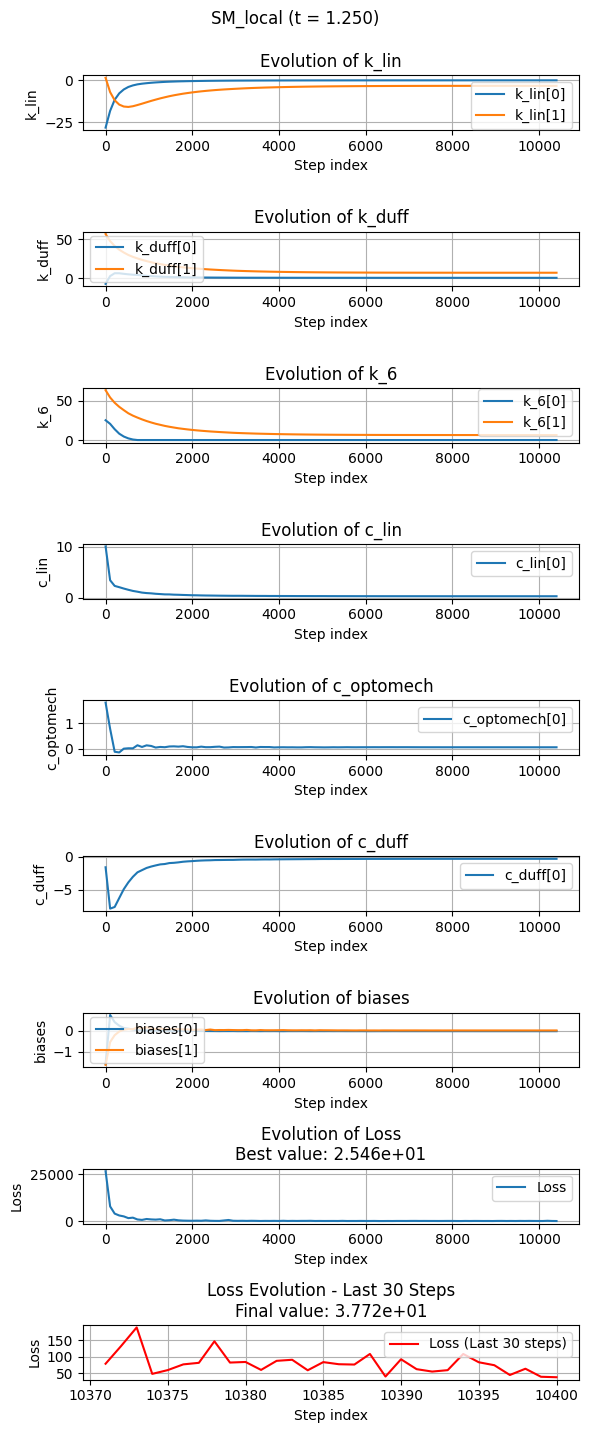

t_idx: 2, t_curr: 2.5
Epoch 0 - Loss: 37.4482 - Best Loss: 37.4482 (Epoch 0)
Epoch 100 - Loss: -9.1244 - Best Loss: -9.9076 (Epoch 96)
Epoch 200 - Loss: -9.7815 - Best Loss: -10.1446 (Epoch 116)
Epoch 300 - Loss: -10.0937 - Best Loss: -10.1446 (Epoch 116)
Epoch 400 - Loss: -9.7720 - Best Loss: -10.1446 (Epoch 116)
Epoch 500 - Loss: -9.5449 - Best Loss: -10.1446 (Epoch 116)
Epoch 600 - Loss: -9.5727 - Best Loss: -10.1507 (Epoch 585)
Epoch 700 - Loss: -9.4514 - Best Loss: -10.3040 (Epoch 671)
Epoch 800 - Loss: -9.9593 - Best Loss: -10.3040 (Epoch 671)
Epoch 900 - Loss: -9.7526 - Best Loss: -10.3040 (Epoch 671)
Epoch 1000 - Loss: -9.5566 - Best Loss: -10.3698 (Epoch 989)
Epoch 1100 - Loss: -9.7091 - Best Loss: -10.3698 (Epoch 989)
Epoch 1200 - Loss: -9.6073 - Best Loss: -10.3698 (Epoch 989)
Epoch 1300 - Loss: -9.8276 - Best Loss: -10.3698 (Epoch 989)
Epoch 1400 - Loss: -9.7012 - Best Loss: -10.3698 (Epoch 989)
Epoch 1500 - Loss: -9.9367 - Best Loss: -10.3698 (Epoch 989)
Epoch 1600 - Loss:

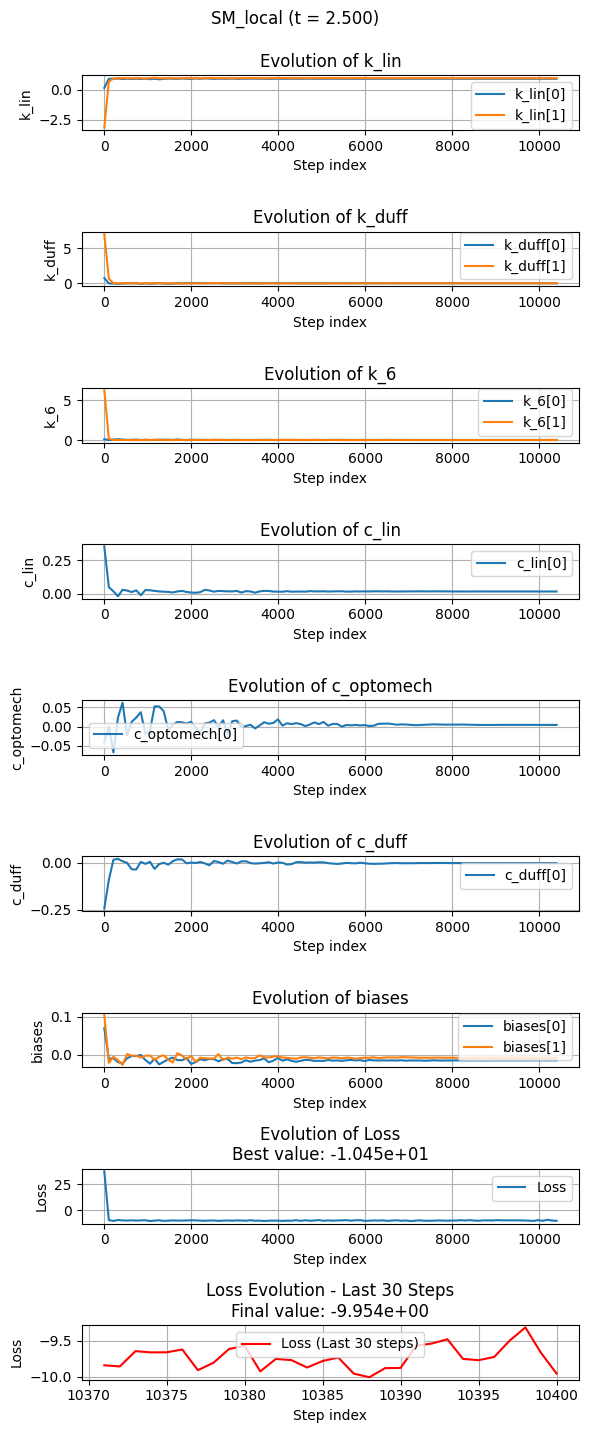

t_idx: 3, t_curr: 3.75
Epoch 0 - Loss: -9.7986 - Best Loss: -9.7986 (Epoch 0)
Epoch 100 - Loss: -10.2334 - Best Loss: -10.5217 (Epoch 96)
Epoch 200 - Loss: -9.8022 - Best Loss: -10.5217 (Epoch 96)
Epoch 300 - Loss: -10.1187 - Best Loss: -10.5217 (Epoch 96)
Epoch 400 - Loss: -9.8747 - Best Loss: -10.5217 (Epoch 96)
Epoch 500 - Loss: -9.6842 - Best Loss: -10.7964 (Epoch 477)
Epoch 600 - Loss: -9.8283 - Best Loss: -10.7964 (Epoch 477)
Epoch 700 - Loss: -10.0323 - Best Loss: -10.7964 (Epoch 477)
Epoch 800 - Loss: -9.8963 - Best Loss: -10.7964 (Epoch 477)
Epoch 900 - Loss: -9.7477 - Best Loss: -10.7964 (Epoch 477)
Epoch 1000 - Loss: -10.2334 - Best Loss: -10.7964 (Epoch 477)
Epoch 1100 - Loss: -10.1219 - Best Loss: -10.7964 (Epoch 477)
Epoch 1200 - Loss: -10.2382 - Best Loss: -10.7964 (Epoch 477)
Epoch 1300 - Loss: -9.8810 - Best Loss: -10.7964 (Epoch 477)
Epoch 1400 - Loss: -9.4997 - Best Loss: -10.7964 (Epoch 477)
Epoch 1500 - Loss: -9.9255 - Best Loss: -10.7964 (Epoch 477)
Epoch 1600 - L

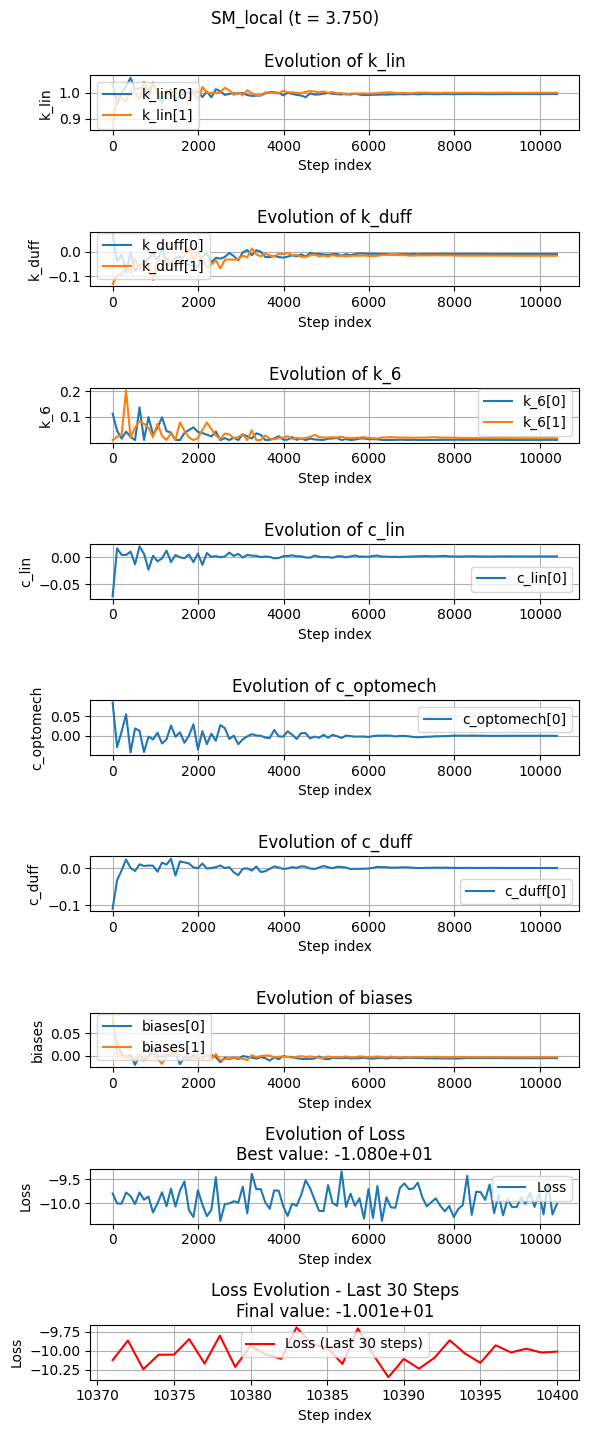

t_idx: 4, t_curr: 5.0
Epoch 0 - Loss: -10.2223 - Best Loss: -10.2223 (Epoch 0)
Epoch 100 - Loss: -9.9787 - Best Loss: -10.5523 (Epoch 85)
Epoch 200 - Loss: -9.9104 - Best Loss: -10.5523 (Epoch 85)
Epoch 300 - Loss: -10.0413 - Best Loss: -10.5523 (Epoch 85)
Epoch 400 - Loss: -10.1937 - Best Loss: -10.5844 (Epoch 336)
Epoch 500 - Loss: -9.5631 - Best Loss: -10.5844 (Epoch 336)
Epoch 600 - Loss: -9.6655 - Best Loss: -10.5844 (Epoch 336)
Epoch 700 - Loss: -10.0415 - Best Loss: -10.5844 (Epoch 336)
Epoch 800 - Loss: -10.2439 - Best Loss: -10.6000 (Epoch 756)
Epoch 900 - Loss: -9.8122 - Best Loss: -10.6000 (Epoch 756)
Epoch 1000 - Loss: -9.9164 - Best Loss: -10.6000 (Epoch 756)
Epoch 1100 - Loss: -10.1727 - Best Loss: -10.6000 (Epoch 756)
Epoch 1200 - Loss: -9.6220 - Best Loss: -10.6975 (Epoch 1140)
Epoch 1300 - Loss: -10.1423 - Best Loss: -10.6975 (Epoch 1140)
Epoch 1400 - Loss: -10.1096 - Best Loss: -10.7280 (Epoch 1356)
Epoch 1500 - Loss: -9.7961 - Best Loss: -10.7280 (Epoch 1356)
Epoch 1

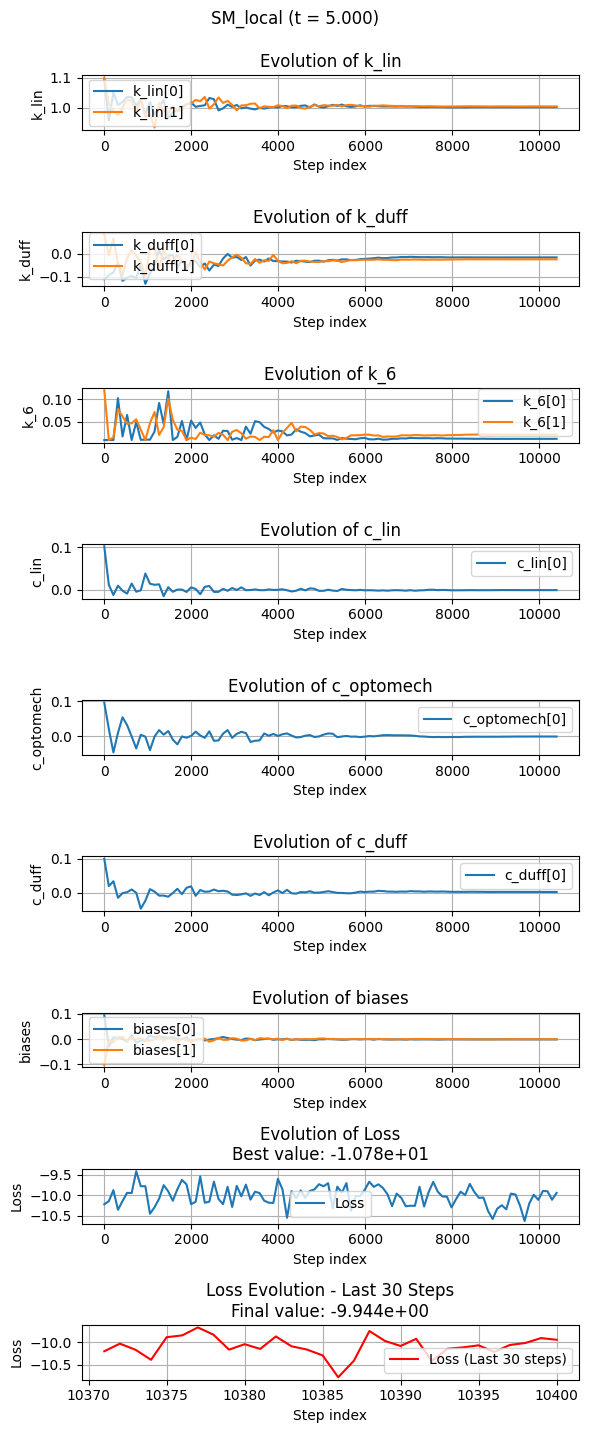

Optimization complete; saved parameters to ../out/problems/2026_01_16/gaussian_mixture/Energy_fn_type_6th_order_duffing_coupling_Temp_0.1/weights_[0.6 0.4]_means_[ 1.   0.5 -1.  -0.5]_covs_[0.001 0.    0.    0.001 0.001 0.    0.    0.001]/training_method_SM_local_exp_time_pts_False_t_forward_5.0_n_timesteps_5_sigma_forward_1.0_lr_0.1_epochs_100000_batch_2048_window_500_tol_0.1_patience_100


In [11]:
params_history_path = f"{output_dir}/params_history.npy"
# if os.path.exists(params_history_path):
#     # Load existing parameters
#     print('Loading existing parameters from', params_history_path)
#     params_history_all_t = jnp.load(params_history_path)
# else:
    # print('No existing parameters found, running optimization')    

# Setup optimization parameters
mask = jnp.ones(params_flattened_initial.shape[0])

# Plotting parameters
plot_steps = True  # Flag to control whether to plot during optimization
plot_slice = 1     # Plot every nth step

params_history_all_t = []
current_params = params_flattened_initial

# Loop over time points
for t_idx, t_curr in enumerate(forward_time_pts):
    print(f"t_idx: {t_idx}, t_curr: {t_curr}")
    optimization_key, optimization_subkey = jr.split(optimization_key)
    
    if t_idx == 0:
        samples_0 = sample_forward_process(t_forward, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_target, key=optimization_key)
        plot_forward_marginals(samples_0, t_forward, sigma_forward, beta=1.0, path=output_dir, save_fig=save_fig, fontsize=16, plot_show=True)
    
    sampler = lambda key: sample_forward_process(
            t_curr, n_samples = batch_size, D=Temp, sigma_final=sigma_forward, samples0=samples_target, key=key, beta= 1
        )
    
    # Perform optimization starting from previous best parameters
    params_history, loss_history, current_params, best_loss, best_epoch = run_optimization(
        loss_fn_per_batch=loss_fn_per_batch,
        params_initial=current_params,
        sampler=sampler,
        mask=mask,
        gradient_fn_per_batch=gradient_fn_per_batch,
        key=optimization_subkey,
        learning_rate=learning_rate,
        n_epochs=n_epochs,
        maximize=maximize,
        window_size=window_size,
        tolerance=tolerance,
        patience=patience,
        constraint_indices=constraint_indices
    )
    
    params_history_all_t.append(current_params)
    
    if plot_steps:
        if t_idx % plot_slice == 0:
            # Plot optimization progress
            plot_parameter_evolution(
                params_history=params_history,
                loss_history=loss_history,
                best_params=current_params,
                best_loss=best_loss,
                best_idx=best_epoch,
                time = t_curr,
                time_index = t_idx,
                unflatten=unflatten,
                N_osc=N_osc,
                # slicing=10,
                title=f"{training_method} (t = {t_curr:.3f})",
                maximize=maximize,
                labels_on=True,
                save_fig=save_fig,
                path=output_dir,
                param_names=params_names,
                plot_show=True
            )
        
# Convert params_history_all_t to array for easier analysis
params_history_all_t = jnp.array(params_history_all_t)
jnp.save(f"{output_dir}/params_history.npy", params_history_all_t)

print('Optimization complete; saved parameters to', output_dir)

### Smoothen and interpolate parameter evolution

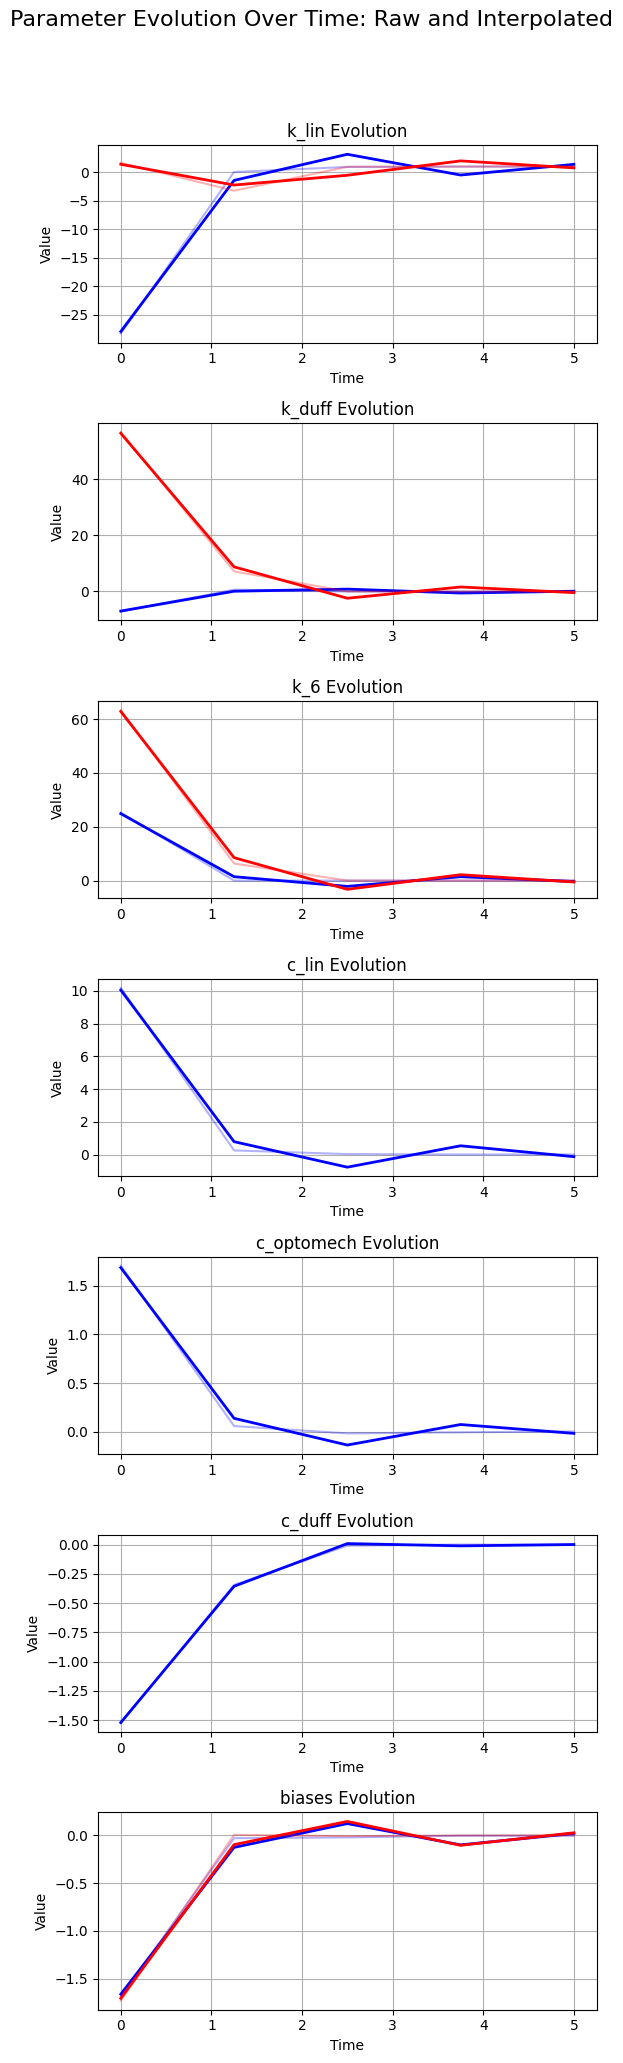

In [12]:
use_smoothed_params = False
smoothed_params = smooth_parameters(params_history_all_t, window_lengths=[10] * params_history_all_t.shape[1], poly_orders=[3] * params_history_all_t.shape[1])

# Get interpolator functions
params_interpolator_smoothed = interpolate_parameters(smoothed_params, forward_time_pts)
params_interpolator_non_smoothed = interpolate_parameters(params_history_all_t, forward_time_pts)

# Then interpolate the smoothed parameters
time_eval = jnp.linspace(forward_time_pts[0], forward_time_pts[-1], 200)
interpolated_params_smoothed = params_interpolator_smoothed(time_eval)
interpolated_params_non_smoothed = params_interpolator_non_smoothed(time_eval)

plot_parameter_as_fn_of_time(params_names, forward_time_pts, forward_time_pts, params_history_all_t, params_interpolator_smoothed, unflatten, N_osc, save_fig=True, path=plot_folder, log_scale=False,plot_show=True)

if use_smoothed_params:
    params_interpolator = params_interpolator_smoothed
else:
    params_interpolator = params_interpolator_non_smoothed

### Run reverse SDE:

In [13]:
forward_params = jnp.zeros_like(params_flattened_initial)
forward_params = forward_params.at[0:N_osc].set(1.)
if Temp == 0.0:
    params_interpolator_reverse_plus_linear = lambda t: params_interpolator(t_forward - t) - 1 / sigma_forward**2 * forward_params
elif training_method == "CD1" or training_method == "SM_local":
    params_interpolator_reverse_plus_linear = lambda t: 2*params_interpolator(t_forward - t) - 1 / sigma_forward**2 * forward_params
else: 
    params_interpolator_reverse_plus_linear = lambda t: 2*Temp*params_interpolator(t_forward - t) - 1 / sigma_forward**2 * forward_params


# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True, Temp=Temp)

t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 100)
dt0 = 0.00000001
atol = 1e-2
rtol = 1e-3

n_trajectories = 2000

# Generate multiple initial states
reverse_sde_key, subkey_initial = jr.split(reverse_sde_key)
initial_states = sample_forward_process(t_forward, n_trajectories, sigma_final=sigma_forward, D=Temp, samples0=samples_target, key=subkey_initial)

# Generate a key for each initial condition
keys_brownian = jr.split(reverse_sde_key, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn,
        diffusion_fn,
        init_state,
        key_b,
        t0,
        t1,
        ts.shape[0],
        dt0,
        rtol=rtol,
        atol=atol
    ),
    in_axes=(0, 0)
)

# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys
final_states = all_trajectories[:, -1, :]

/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.wa

### Run equillibirum SDE

In [14]:
t1 = n_trajectories*t_forward*0.00001
sde_samples_direct_path = f"{output_dir}/sde_samples_direct_simT_{t1}.npy"
if os.path.exists(sde_samples_direct_path):
    # Load existing parameters
    print('Loading existing equilibrium trajectory', sde_samples_direct_path)
    sde_samples_direct = jnp.load(sde_samples_direct_path)
else:
    print('No existing equilibrium trajectory found, running optimization')   
    drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator(0), N_osc, Temp=Temp, time_dependent_parms=False)
    t0 = 0.0
    ts = jnp.linspace(t0, t1, n_trajectories)
    dt0 = ts[1] - ts[0]
    initial_state = jnp.array([-.0,0.])

    reverse_sde_key, subkey_direct = jr.split(reverse_sde_key)
    solution_direct = solve_SDE(drift_fn, diffusion_fn, initial_state,subkey_direct, t0, t1, ts.shape[0], dt0,atol=atol,rtol=rtol)
    sde_samples_direct = solution_direct.ys
    jnp.save(f"{output_dir}/sde_samples_direct.npy", sde_samples_direct)


No existing equilibrium trajectory found, running optimization


/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.wa

## Plot samples

    Reverse Trajectory total prob ≈ 1.000000
  Equilibrium Sampling total prob ≈ 1.000000


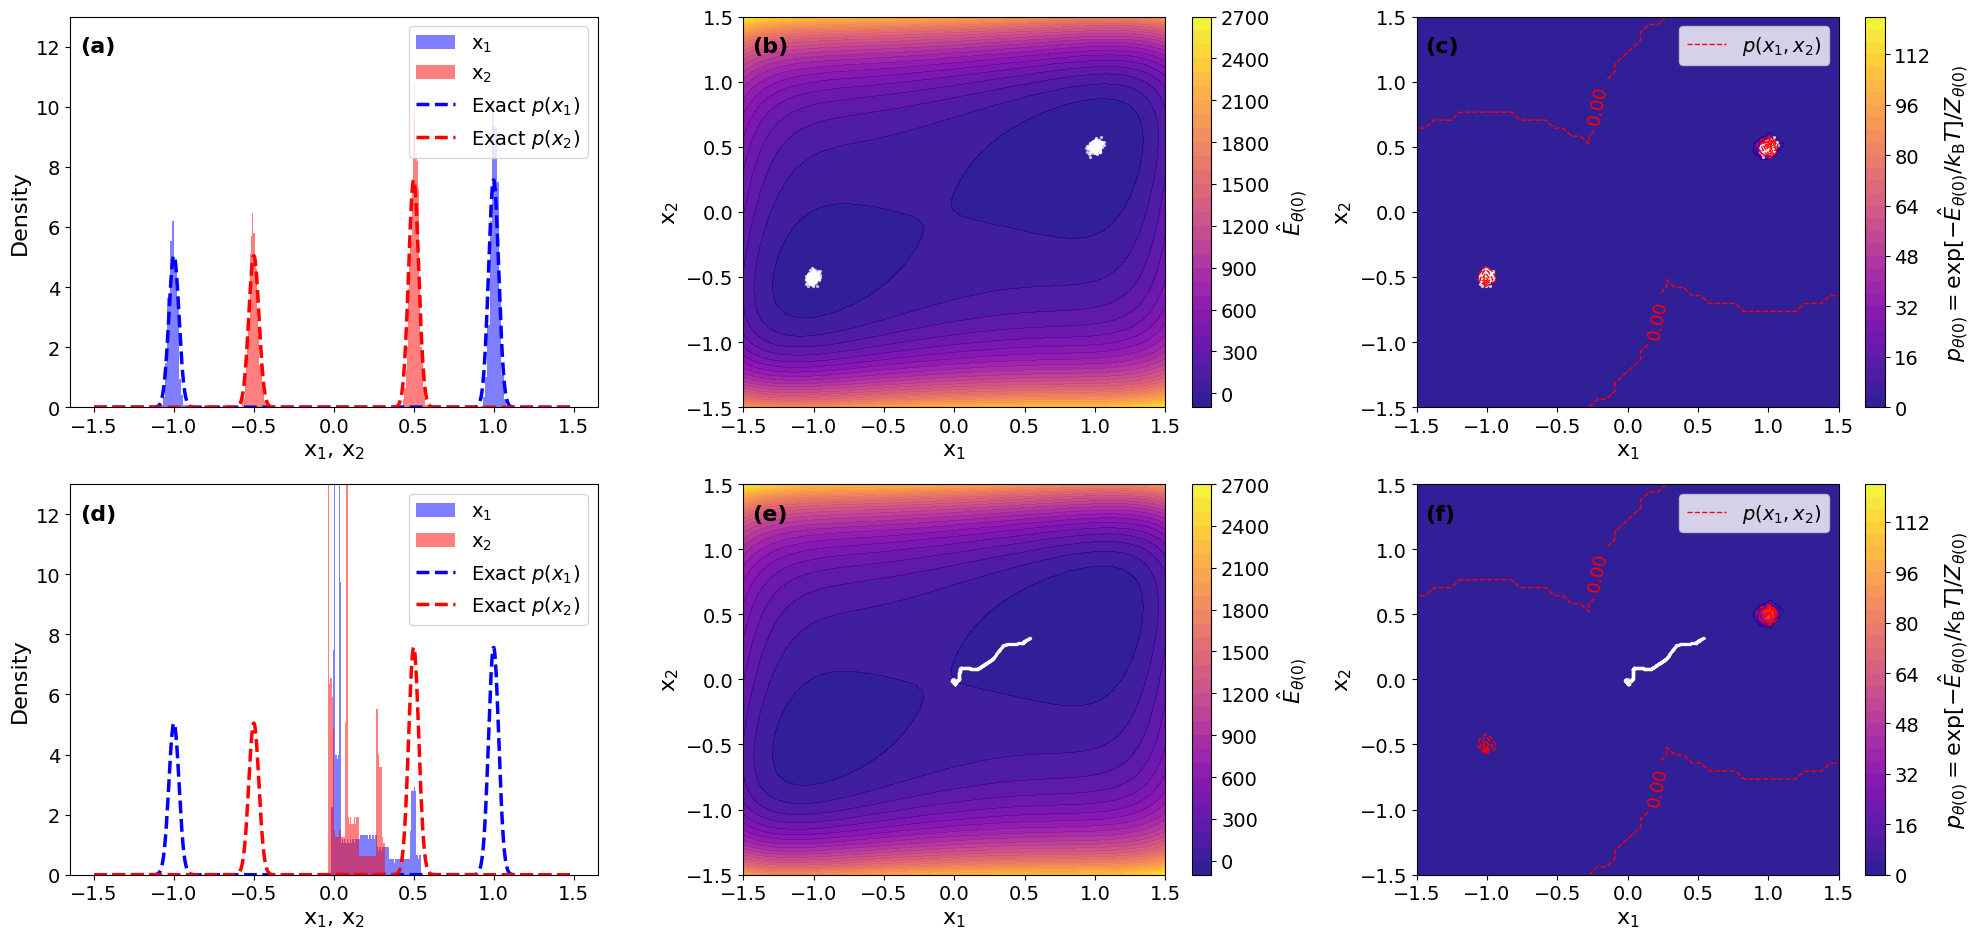

In [15]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

# high-contrast violet→red
viored = LinearSegmentedColormap.from_list("viored", ["violet", "red"])

def plot_prl_comparison_with_iso_label(
    energy_fn,
    params_reverse,
    params_equil,
    reverse_samples,
    sde_samples_direct,
    weights, means, covs,       # GMM params
    *,                           # everything below here must be named
    x1_range=(-1.5, 1.5),
    x2_range=(-1.5, 1.5),
    n_points=200,
    num_bins=100,
    sample_stride=10,
    figsize=(7, 4),
    fontsize=10,
    label_fontsize=14,           # increased default label fontsize
    iso_levels=5,                # number of iso–contour levels
):
    # 1) Grid
    x1 = jnp.linspace(x1_range[0], x1_range[1], n_points)
    x2 = jnp.linspace(x2_range[0], x2_range[1], n_points)
    X1, X2 = jnp.meshgrid(x1, x2)
    dx, dy = x1[1] - x1[0], x2[1] - x2[0]

    # 2) Exact marginals for histograms
    x_lin = jnp.linspace(x1_range[0], x1_range[1], 1000)
    marginal_x1 = sum(
        w * jnp.exp(-0.5*((x_lin - m[0])**2)/C[0,0]) / jnp.sqrt(2*jnp.pi*C[0,0])
        for w,m,C in zip(weights, means, covs)
    )
    marginal_x2 = sum(
        w * jnp.exp(-0.5*((x_lin - m[1])**2)/C[1,1]) / jnp.sqrt(2*jnp.pi*C[1,1])
        for w,m,C in zip(weights, means, covs)
    )

    # 3) True 2D GMM density on grid
    true_prob = jnp.zeros_like(X1)
    for w, m, C in zip(weights, means, covs):
        diff = jnp.stack([X1 - m[0], X2 - m[1]], axis=-1)
        invC = jnp.linalg.inv(C)
        exponent = jnp.einsum('...i,ij,...j->...', diff, invC, diff)
        norm = jnp.sqrt((2*jnp.pi)**2 * jnp.linalg.det(C))
        true_prob += w * jnp.exp(-0.5 * exponent) / norm

    # 4) Compute E & model P for both methods
    E_list, P_list = [], []
    for params in (params_reverse, params_equil):
        E = jnp.zeros_like(X1)
        for i in range(n_points):
            for j in range(n_points):
                x = jnp.array([X1[i,j], X2[i,j]])
                E = E.at[i,j].set(energy_fn(x, params))
        P = jnp.exp(-E)
        P /= (jnp.sum(P) * dx * dy)
        E_list.append(E)
        P_list.append(P)

    # 5) Figure setup
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    labels = ['(a)','(b)','(c)','(d)','(e)','(f)']
    for ax, lab in zip(axes.flatten(), labels):
        ax.text(0.02, 0.95, lab,
                transform=ax.transAxes,
                fontsize=label_fontsize,
                fontweight='bold',
                va='top', ha='left')

    row_titles = ['Reverse Trajectory', 'Equilibrium Sampling']

    # 6) Plot rows
    for row, (title, samples) in enumerate(zip(row_titles,
                                              (reverse_samples, sde_samples_direct))):
        # — combined marginals
        ax = axes[row,0]
        ax.hist(samples[:,0], bins=num_bins, density=True,
                alpha=0.5, color='blue', label='x$_1$')
        ax.hist(samples[:,1], bins=num_bins, density=True,
                alpha=0.5, color='red',  label='x$_2$')
        ax.plot(x_lin, marginal_x1, '--b', lw=2.5, label='Exact $p(x_1)$')
        ax.plot(x_lin, marginal_x2, '--r', lw=2.5, label='Exact $p(x_2)$')
        ax.set_ylim(0, 13)
        ax.set_xlabel('x$_1$, x$_2$', fontsize=fontsize)
        ax.set_ylabel('Density', fontsize=fontsize)
        ax.legend(fontsize=fontsize-2, loc='upper right')
        ax.tick_params(labelsize=fontsize-2)

        # — energy map
        ax = axes[row,1]
        cf = ax.contourf(X1, X2, E_list[row], levels=30,
                         cmap='plasma', alpha=0.9)
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(r'$\hat{E}_{\theta(0)}$', fontsize=label_fontsize)
        cbar.ax.tick_params(labelsize=label_fontsize-2)
        ax.scatter(samples[::sample_stride,0],
                   samples[::sample_stride,1],
                   c='white', s=2, alpha=0.6)
        ax.set_xlabel('x$_1$', fontsize=fontsize)
        ax.set_ylabel('x$_2$', fontsize=fontsize)
        ax.tick_params(labelsize=fontsize-2)

        # — probability map + iso contours + legend entry
        ax = axes[row,2]
        cf = ax.contourf(X1, X2, P_list[row], levels=30,
                         cmap='plasma', alpha=0.9)
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(
            r'$p_{\theta(0)} = \exp[-\hat{E}_{\theta(0)}/k_\mathrm{B}T]/Z_{\theta(0)}$',
            fontsize=label_fontsize
        )
        cbar.ax.tick_params(labelsize=label_fontsize-2)
        ax.scatter(samples[::sample_stride,0],
                   samples[::sample_stride,1],
                   c='white', s=2, alpha=0.6)
        iso = ax.contour(X1, X2, true_prob,
                         levels=iso_levels,
                         colors='red',
                         linestyles='--',
                         linewidths=1)
        ax.clabel(iso, fmt='%.2f', fontsize=fontsize-3)
        iso_proxy = Line2D(
            [0],[0],
            color='red',
            linestyle='--',
            linewidth=1,
            label=r'$p(x_1,x_2)$'
        )
        ax.legend(handles=[iso_proxy], fontsize=fontsize-2, loc='upper right')

        ax.set_xlabel('x$_1$', fontsize=fontsize)
        ax.set_ylabel('x$_2$', fontsize=fontsize)
        ax.tick_params(labelsize=fontsize-2)

        # sanity check
        tot = jnp.sum(P_list[row]) * dx * dy
        print(f"{title:>22} total prob ≈ {tot:.6f}")

    fig.tight_layout(rect=[0,0,1,0.95])
    plt.savefig(f"{plot_folder}/fig_2D_mixture_comparison_Temp_{Temp}_num_traj_{n_trajectories}.png", dpi=300, bbox_inches='tight')
    plt.show()
    


# Example call:
plot_prl_comparison_with_iso_label(
    energy_fn,
    params_interpolator(0)/Temp,
    params_interpolator(0)/Temp,
    final_states,
    sde_samples_direct,
    weights, means, covs,          # GMM params
    n_points=50,
    num_bins=150,
    sample_stride=5,
    x1_range=(-1.5,1.5),
    x2_range=(-1.5,1.5),
    figsize=(20,10),
    fontsize=16,
    label_fontsize=16,
    iso_levels=7,
)


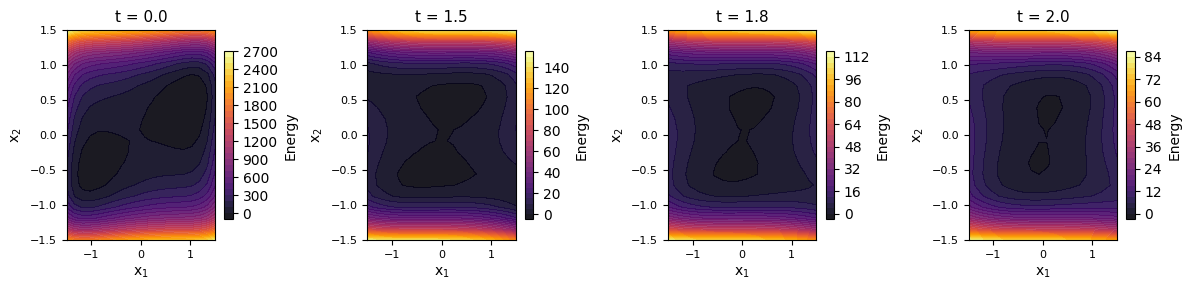

In [16]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# high‐contrast violet→red
viored = LinearSegmentedColormap.from_list("viored", ["violet", "red"])

def plot_energy_timepoints(
    energy_fn,
    params_interpolator,
    Temp,
    time_points=(0.0, 0.5, 1.0, 1.5),
    x1_range=(-1.5, 1.5),
    x2_range=(-1.5, 1.5),
    n_points=200,
    figsize=(12, 3),
    fontsize=10,
):
    """
    Plot energy landscapes at multiple time points side by side.

    Args:
        energy_fn:    fn(x, params) → scalar energy
        params_interpolator:  fn(t) → raw params
        Temp:         temperature scalar (divide params by Temp)
        time_points:  iterable of t values
        x1_range:     (min, max) for x₁
        x2_range:     (min, max) for x₂
        n_points:     grid resolution per axis
        figsize:      overall figure size (width, height)
        fontsize:     base font size for labels & titles
    """
    # build grid
    x1 = jnp.linspace(x1_range[0], x1_range[1], n_points)
    x2 = jnp.linspace(x2_range[0], x2_range[1], n_points)
    X1, X2 = jnp.meshgrid(x1, x2)

    fig, axes = plt.subplots(1, len(time_points), figsize=figsize, squeeze=False)
    axes = axes[0]

    for ax, t in zip(axes, time_points):
        # compute energy on grid
        params = params_interpolator(t) / Temp
        E = jnp.zeros_like(X1)
        for i in range(n_points):
            for j in range(n_points):
                x = jnp.array([X1[i, j], X2[i, j]])
                E = E.at[i, j].set(energy_fn(x, params))

        # plot
        cf = ax.contourf(X1, X2, E, levels=30, cmap='inferno', alpha=0.9)
        plt.colorbar(cf, ax=ax, label='Energy', shrink=0.8)
        ax.set_title(f"t = {t}", fontsize=fontsize+1)
        ax.set_xlabel('x$_1$', fontsize=fontsize)
        ax.set_ylabel('x$_2$', fontsize=fontsize)
        ax.tick_params(labelsize=fontsize-2)

    fig.tight_layout()
    plt.show()


# USAGE EXAMPLE
plot_energy_timepoints(
    energy_fn,
    params_interpolator,
    Temp,
    time_points=(0.0, 1.5, 1.8, 2.0),
    x1_range=(-1.5, 1.5),
    x2_range=(-1.5, 1.5),
    n_points=20,
    figsize=(12,3),
    fontsize=10,
)


In [17]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

# Print-friendly color schemes with high contrast
# Option 1: Grayscale with high contrast (best for B&W printing)
grayscale_cmap = LinearSegmentedColormap.from_list("grayscale_contrast", 
                                                   ["white", "lightgray", "gray", "darkgray", "black"])

# Option 2: Blue-white-red diverging (good contrast, colorblind friendly)
bwr_cmap = LinearSegmentedColormap.from_list("blue_white_red", 
                                             ["darkblue", "blue", "lightblue", "white", 
                                              "lightcoral", "red", "darkred"])

# Option 3: Viridis-like but with higher contrast
viridis_contrast = LinearSegmentedColormap.from_list("viridis_contrast",
                                                     ["#440154", "#31688e", "#35b779", "#fde725"])

# Option 4: Custom high-contrast scheme (purple to yellow)
purple_yellow = LinearSegmentedColormap.from_list("purple_yellow",
                                                  ["#2d1b69", "#5d2a8a", "#8e44ad", "#c39bd3", 
                                                   "#f7dc6f", "#f4d03f", "#f1c40f"])

def plot_prl_comparison_print_friendly(
    energy_fn,
    params_reverse,
    params_equil,
    reverse_samples,
    sde_samples_direct,
    weights, means, covs,       # GMM params
    *,                           # everything below here must be named
    x1_range=(-1.5, 1.5),
    x2_range=(-1.5, 1.5),
    n_points=200,
    num_bins=50,
    sample_stride=10,
    figsize=(7, 4),
    fontsize=10,
    label_fontsize=14,
    iso_levels=5,
    colormap='grayscale',        # NEW: colormap option
    contour_linewidth=2.0,       # NEW: thicker contour lines
    scatter_size=3,              # NEW: larger scatter points
    scatter_alpha=0.8,           # NEW: higher alpha for visibility
):
    """
    Print-friendly version with improved color schemes and visibility.
    
    colormap options:
    - 'grayscale': High-contrast grayscale (best for B&W printing)
    - 'bwr': Blue-white-red diverging
    - 'viridis_contrast': High-contrast viridis-like
    - 'purple_yellow': Purple to yellow high contrast
    - 'plasma': Original plasma (for comparison)
    """
    
    # Select colormap
    cmap_dict = {
        'grayscale': grayscale_cmap,
        'bwr': bwr_cmap,
        'viridis_contrast': viridis_contrast,
        'purple_yellow': purple_yellow,
        'plasma': 'plasma'
    }
    selected_cmap = cmap_dict.get(colormap, grayscale_cmap)
    
    # 1) Grid
    x1 = jnp.linspace(x1_range[0], x1_range[1], n_points)
    x2 = jnp.linspace(x2_range[0], x2_range[1], n_points)
    X1, X2 = jnp.meshgrid(x1, x2)
    dx, dy = x1[1] - x1[0], x2[1] - x2[0]

    # 2) Exact marginals for histograms
    x_lin = jnp.linspace(x1_range[0], x1_range[1], 1000)
    marginal_x1 = sum(
        w * jnp.exp(-0.5*((x_lin - m[0])**2)/C[0,0]) / jnp.sqrt(2*jnp.pi*C[0,0])
        for w,m,C in zip(weights, means, covs)
    )
    marginal_x2 = sum(
        w * jnp.exp(-0.5*((x_lin - m[1])**2)/C[1,1]) / jnp.sqrt(2*jnp.pi*C[1,1])
        for w,m,C in zip(weights, means, covs)
    )

    # 3) True 2D GMM density on grid
    true_prob = jnp.zeros_like(X1)
    for w, m, C in zip(weights, means, covs):
        diff = jnp.stack([X1 - m[0], X2 - m[1]], axis=-1)
        invC = jnp.linalg.inv(C)
        exponent = jnp.einsum('...i,ij,...j->...', diff, invC, diff)
        norm = jnp.sqrt((2*jnp.pi)**2 * jnp.linalg.det(C))
        true_prob += w * jnp.exp(-0.5 * exponent) / norm

    # 4) Compute E & model P for both methods
    E_list, P_list = [], []
    for params in (params_reverse, params_equil):
        E = jnp.zeros_like(X1)
        for i in range(n_points):
            for j in range(n_points):
                x = jnp.array([X1[i,j], X2[i,j]])
                E = E.at[i,j].set(energy_fn(x, params))
        P = jnp.exp(-E)
        P /= (jnp.sum(P) * dx * dy)
        E_list.append(E)
        P_list.append(P)

    # 5) Figure setup with improved styling
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    labels = ['(a)','(b)','(c)','(d)','(e)','(f)']
    for ax, lab in zip(axes.flatten(), labels):
        ax.text(0.02, 0.95, lab,
                transform=ax.transAxes,
                fontsize=label_fontsize,
                fontweight='bold',
                va='top', ha='left',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    row_titles = ['Reverse Trajectory', 'Equilibrium Sampling']

    # 6) Plot rows with improved visibility
    for row, (title, samples) in enumerate(zip(row_titles,
                                              (reverse_samples, sde_samples_direct))):
        # — combined marginals with thicker lines
        ax = axes[row,0]
        ax.hist(samples[:,0], bins=num_bins, density=True,
                alpha=0.6, color='blue', label='x$_1$', edgecolor='darkblue', linewidth=0.5)
        ax.hist(samples[:,1], bins=num_bins, density=True,
                alpha=0.6, color='red',  label='x$_2$', edgecolor='darkred', linewidth=0.5)
        ax.plot(x_lin, marginal_x1, '--', color='darkblue', lw=3, label='Exact $p(x_1)$')
        ax.plot(x_lin, marginal_x2, '--', color='darkred', lw=3, label='Exact $p(x_2)$')
        ax.set_ylim(0, 13)
        ax.set_xlabel('x$_1$, x$_2$', fontsize=fontsize)
        ax.set_ylabel('Density', fontsize=fontsize)
        ax.legend(fontsize=fontsize-2, loc='upper right')
        ax.tick_params(labelsize=fontsize-2)
        ax.grid(True, alpha=0.3)

        # — energy map with improved colormap
        ax = axes[row,1]
        cf = ax.contourf(X1, X2, E_list[row], levels=30,
                         cmap=selected_cmap, alpha=0.95)
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(r'$\hat{E}_{\theta(0)}$', fontsize=label_fontsize)
        cbar.ax.tick_params(labelsize=label_fontsize-2)
        
        # Improved scatter points
        scatter_color = 'white' if colormap == 'grayscale' else 'black'
        ax.scatter(samples[::sample_stride,0],
                   samples[::sample_stride,1],
                   c=scatter_color, s=scatter_size, alpha=scatter_alpha,
                   edgecolors='black' if scatter_color == 'white' else 'white',
                   linewidths=0.5)
        ax.set_xlabel('x$_1$', fontsize=fontsize)
        ax.set_ylabel('x$_2$', fontsize=fontsize)
        ax.tick_params(labelsize=fontsize-2)

        # — probability map with improved contours
        ax = axes[row,2]
        cf = ax.contourf(X1, X2, P_list[row], levels=30,
                         cmap=selected_cmap, alpha=0.95)
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(
            r'$p_{\theta(0)} = \exp[-\hat{E}_{\theta(0)}/k_\mathrm{B}T]/Z_{\theta(0)}$',
            fontsize=label_fontsize
        )
        cbar.ax.tick_params(labelsize=label_fontsize-2)
        
        # Improved scatter points
        ax.scatter(samples[::sample_stride,0],
                   samples[::sample_stride,1],
                   c=scatter_color, s=scatter_size, alpha=scatter_alpha,
                   edgecolors='black' if scatter_color == 'white' else 'white',
                   linewidths=0.5)
        
        # Thicker, more visible contour lines
        iso = ax.contour(X1, X2, true_prob,
                         levels=iso_levels,
                         colors='yellow',
                         linestyles='--',
                         linewidths=contour_linewidth)
        ax.clabel(iso, fmt='%.2f', fontsize=fontsize-2, inline=True)
        
        iso_proxy = Line2D(
            [0],[0],
            color='yellow',
            linestyle='--',
            linewidth=contour_linewidth,
            label=r'$p(x_1,x_2)$'
        )
        ax.legend(handles=[iso_proxy], fontsize=fontsize-2, loc='upper right')

        ax.set_xlabel('x$_1$', fontsize=fontsize)
        ax.set_ylabel('x$_2$', fontsize=fontsize)
        ax.tick_params(labelsize=fontsize-2)

        # sanity check
        tot = jnp.sum(P_list[row]) * dx * dy
        print(f"{title:>22} total prob ≈ {tot:.6f}")

    # fig.suptitle(f'Print-Friendly Version (colormap: {colormap})', fontsize=label_fontsize+2)
    fig.tight_layout(rect=[0,0,1,0.95])
    
    # Save with colormap info in filename
    plt.savefig(f"{plot_folder}/fig_2D_mixture_comparison_print_friendly_{colormap}_Temp_{Temp}_num_traj_{n_trajectories}_atol_{atol}_rtol_{rtol}.png", 
                dpi=300, bbox_inches='tight')
    plt.show()

print("Available colormap options:")
print("- 'grayscale': High-contrast grayscale (best for B&W printing)")
print("- 'bwr': Blue-white-red diverging") 
print("- 'viridis_contrast': High-contrast viridis-like")
print("- 'purple_yellow': Purple to yellow high contrast")
print("- 'plasma': Original plasma (for comparison)")


Available colormap options:
- 'grayscale': High-contrast grayscale (best for B&W printing)
- 'bwr': Blue-white-red diverging
- 'viridis_contrast': High-contrast viridis-like
- 'purple_yellow': Purple to yellow high contrast
- 'plasma': Original plasma (for comparison)



=== BLUE-WHITE-RED VERSION (Colorblind friendly) ===
    Reverse Trajectory total prob ≈ 1.000000
  Equilibrium Sampling total prob ≈ 1.000000


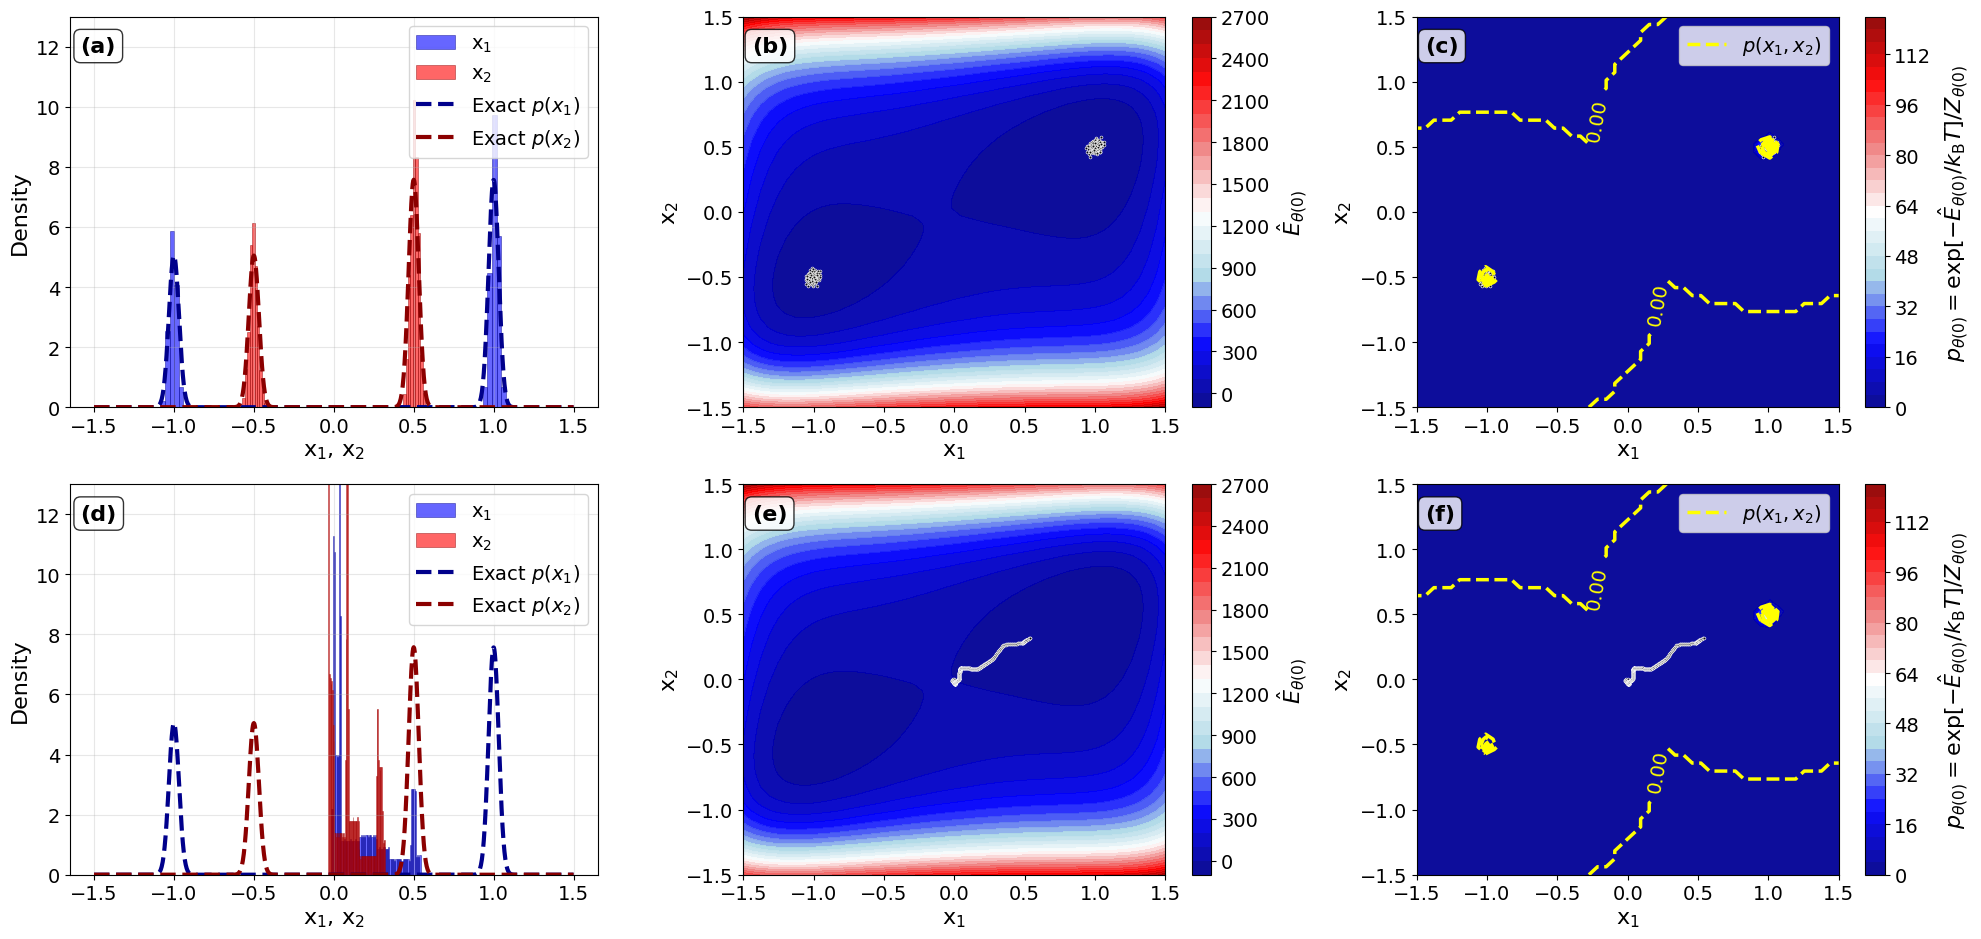

In [18]:
# Example usage with different colormap options
# Test the print-friendly version with different color schemes

# # Grayscale version (best for B&W printing)
# print("=== GRAYSCALE VERSION (Best for B&W printing) ===")
# plot_prl_comparison_print_friendly(
#     energy_fn,
#     params_interpolator(0)/Temp,
#     params_interpolator(0)/Temp,
#     final_states,
#     sde_samples_direct,
#     weights, means, covs,
#     n_points=50,
#     num_bins=150,
#     sample_stride=5,
#     x1_range=(-1.5,1.5),
#     x2_range=(-1.5,1.5),
#     figsize=(20,10),
#     fontsize=16,
#     label_fontsize=16,
#     iso_levels=7,
#     colormap='grayscale',
#     contour_linewidth=2.5,
#     scatter_size=4,
#     scatter_alpha=0.9
# )

# Blue-white-red diverging version (colorblind friendly)
print("\n=== BLUE-WHITE-RED VERSION (Colorblind friendly) ===")
plot_prl_comparison_print_friendly(
    energy_fn,
    params_interpolator(0)/Temp,
    params_interpolator(0)/Temp,
    final_states,
    sde_samples_direct,
    weights, means, covs,
    n_points=50,
    num_bins=75,
    sample_stride=5,
    x1_range=(-1.5,1.5),
    x2_range=(-1.5,1.5),
    figsize=(20,10),
    fontsize=16,
    label_fontsize=16,
    iso_levels=7,
    colormap='bwr',
    contour_linewidth=2.5,
    scatter_size=4,
    scatter_alpha=0.9
)

# # High-contrast viridis version
# print("\n=== HIGH-CONTRAST VIRIDIS VERSION ===")
# plot_prl_comparison_print_friendly(
#     energy_fn,
#     params_interpolator(0)/Temp,
#     params_interpolator(0)/Temp,
#     final_states,
#     sde_samples_direct,
#     weights, means, covs,
#     n_points=50,
#     num_bins=150,
#     sample_stride=5,
#     x1_range=(-1.5,1.5),
#     x2_range=(-1.5,1.5),
#     figsize=(20,10),
#     fontsize=16,
#     label_fontsize=16,
#     iso_levels=7,
#     colormap='viridis_contrast',
#     contour_linewidth=2.5,
#     scatter_size=4,
#     scatter_alpha=0.9
# )
